## Full Lab 2 
This lab is designed further our understanding of Time response functions for first order systems. We look a two types of systems, an RC circuit and a termocouple. 

In [345]:
# Importing packages
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd

In [346]:
#Loading datasets
filepath = '/Users/epalmer/MET4400C_Ins-obs_labs/Labs/lab_2_files/Data_L2'
data_RC = pd.read_csv(f'{filepath}/Full_Lab_2_RC_data.CSV', header=36)
data_ThermoC = pd.read_csv(f'{filepath}/Full_Lab_2_Thermocouple_data.CSV', header = 36)
#data_RC
#data_ThermoC


In [347]:
# Getting the voltage in volts by extracting the column with the data from the dataframe
vRC = data_RC['101 (Vdc)- RC_DCV']
#vRC # looking at the data 

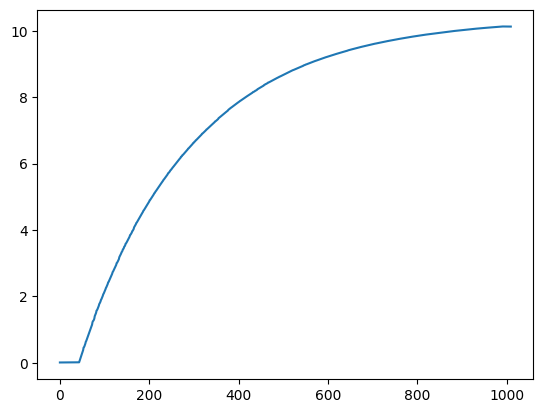

In [348]:
# plotting voltage (Looking at the overall shape of the data to find where the forcing starts)
plt.plot(vRC)

Text(0.5, 1.0, 'Zoomed in Voltage Data')

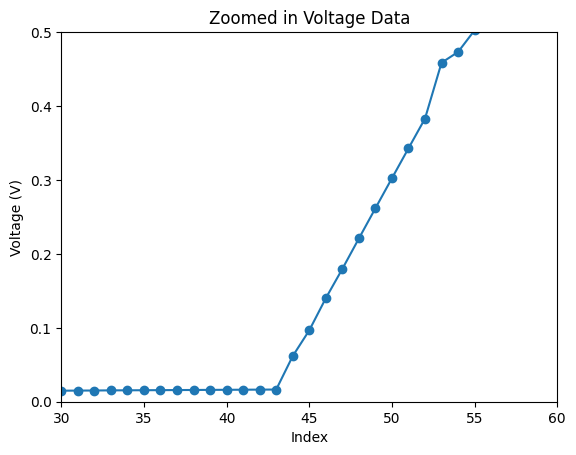

In [349]:
# Zooming in to find the index where the forcing starts
plt.plot(vRC , marker = 'o')
plt.xlim(30, 60)
plt.ylim(0,0.5)
plt.ylabel('Voltage (V)')
plt.xlabel('Index')
plt.title('Zoomed in Voltage Data')


In [350]:
# Setting up a time index instead of just numbers 
timestep = 0.1 #seconds per time step
t_0 = 0 # initial time
i0 =  42 # starting index 

Text(0.5, 1.0, 'Voltage Data with Forcing Start Point')

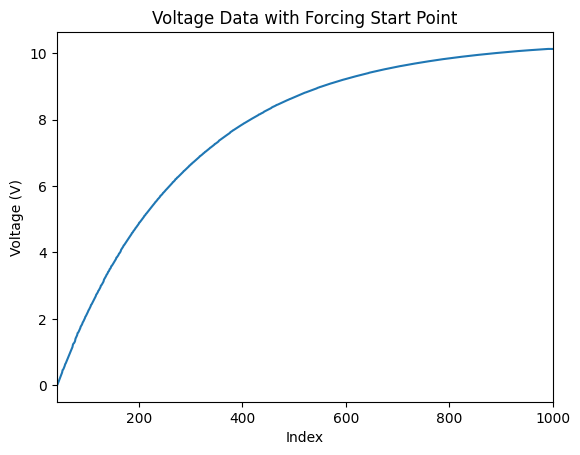

In [351]:
# Find the point where the step forcing stops
plt.plot(vRC)
plt.xlim(i0, 1000)
plt.ylabel('Voltage (V)')
plt.xlabel('Index')
plt.title('Voltage Data with Forcing Start Point')

In [352]:
# We are looking for the point where the voltage begins to level off. 
i1 = 500 # point where it starts to level off (ending index) 
t_end = (i1 - i0) * timestep # Ending time in seconds
print (f'Ends at {t_end:.2f} seconds')

Ends at 45.80 seconds


In [353]:
#creating a time array
t = np.arange(t_0, t_end, timestep)
#t

Text(0.5, 1.0, 'Voltage vs Time in area of leveling off')

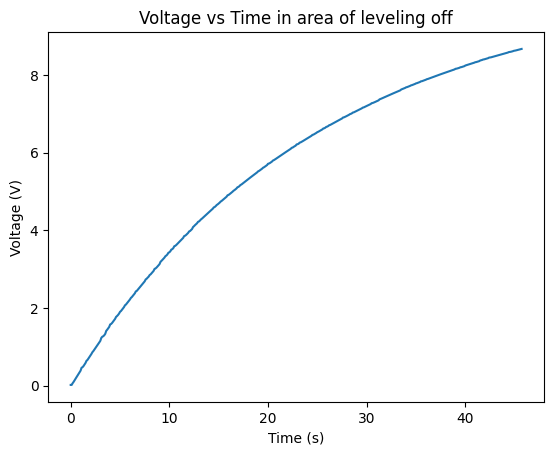

In [354]:
# Voltage vs time t plot
plt.plot(t, vRC[i0:i1])
plt.xlabel('Time (s)')
plt.ylabel('Voltage (V)')
plt.title('Voltage vs Time in area of leveling off')

In [355]:
# Set excitation voltage to E as maxiumum voltage reached by capacitor
E = 10 #Maximum voltage reached by capacitor

Text(0.5, 1.0, 'Fraction of completion vs Time')

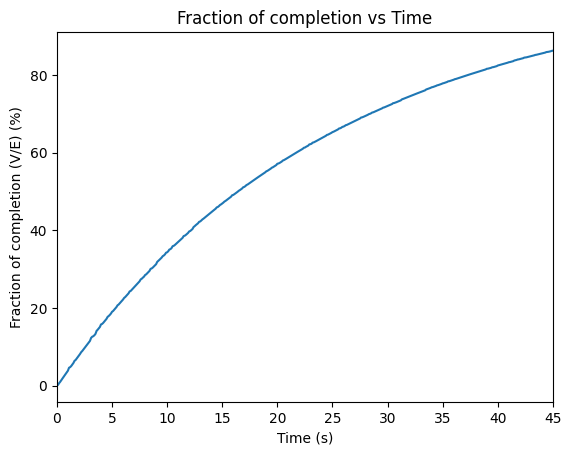

In [356]:
# Calculate the fraction of completion as V/E, starting at t = 0
f = vRC[i0:i1] / E * 100
plt.plot(t,f)
plt.xlabel('Time (s)')
plt.ylabel('Fraction of completion (V/E) (%)')
plt.xlim(0, 45)
plt.title('Fraction of completion vs Time')

In [357]:
# Calculate the tau as inverse slope f -ln(1-f) , and fit a line to it
x = t
y = -np.log(1-f/100)
m = np.sum((x - np.mean(x)) * (y - np.mean(y))) / np.sum((x - np.mean(x))**2) 
b = np.mean(y) - m * np.mean(x)
tau = 1/m


Text(0.5, 1.0, 'Inverse Slope fraction of completion vs Time')

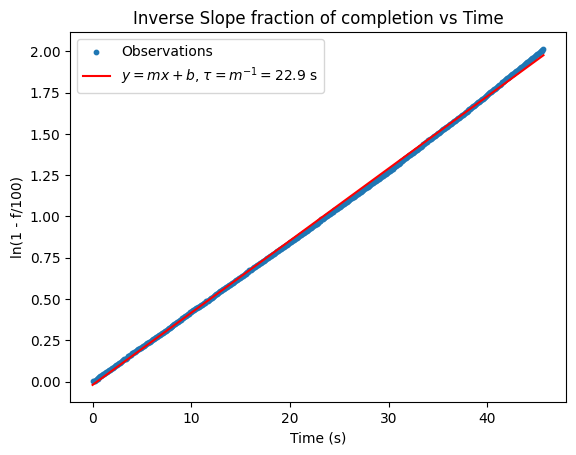

In [358]:
# Plotting scatter plot and the fitted line
plt.scatter(x, y, s = 10 , label='Observations')
plt.plot(x, m*x + b, color='red', label=r'$y=mx+b$, $\tau = m^{-1} = %.1f$ s' % tau)
plt.xlabel('Time (s)')
plt.ylabel('ln(1 - f/100)')
plt.legend()
plt.title('Inverse Slope fraction of completion vs Time')

## Moving onto Thermocouple section ##

In [359]:
# Defining variables needed
T = data_ThermoC['101 (°C)- Tj']

Text(0.5, 1.0, 'Temperature vs Index')

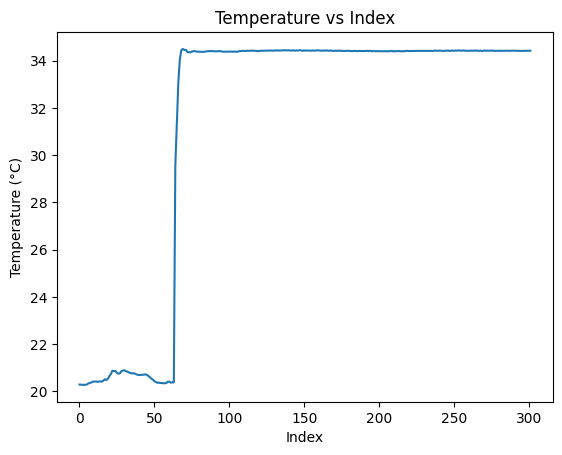

In [360]:
# Plotting Temperature vs time
plt.plot(T)
plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Index')

Text(0.5, 1.0, 'Zoomed in Temperature Data')

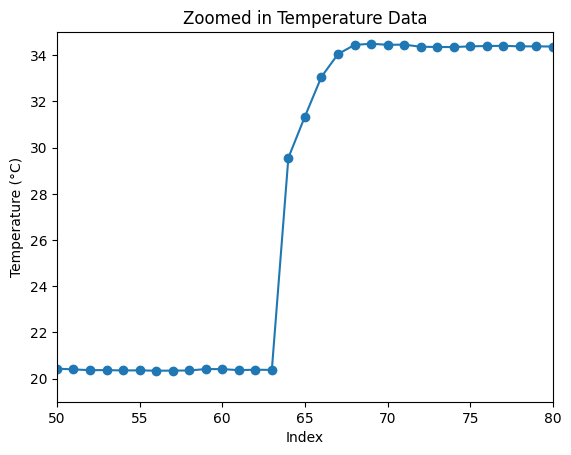

In [361]:
plt.plot(T , marker = 'o')
plt.xlim(50, 80)
plt.ylim(19, 35)
plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.title('Zoomed in Temperature Data')

In [362]:
# Setting up a time index instead of just numbers 
timestep = 0.1 #seconds per time step || already defined above but redefining here for clarity 
t_0_t = 0 
i0_t = 63 # starting index

Text(0.5, 1.0, 'Temperature Data with Forcing Start Point')

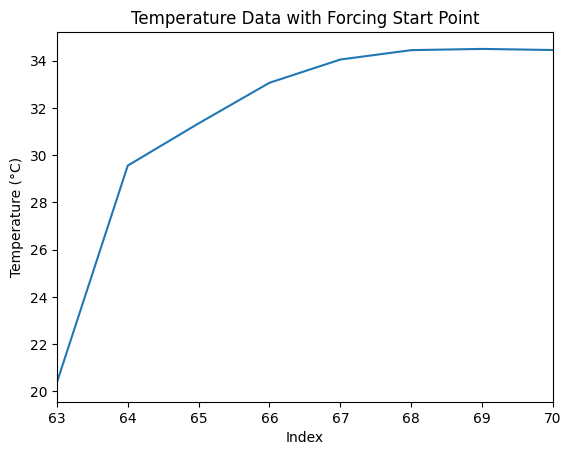

In [363]:
# finding where the temperature/forcing starts to level off
plt.plot(T)
plt.xlim(i0_t, 70)
plt.xlabel('Index')
plt.ylabel('Temperature (°C)')
plt.title('Temperature Data with Forcing Start Point')

In [364]:
i1_t = 69 #Ending index
t1T = (i1_t-i0_t)*timestep #Ending time
print(f'Ends at {t1T:.2f} seconds')

Ends at 0.60 seconds


In [365]:
#Create time axis as seconds since time t=0
temp_t = np.arange(t_0_t,t1T,timestep)
temp_t

array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6])

63    20.377211
64    29.558709
65    31.345267
66    33.064624
67    34.047859
68    34.446041
Name: 101 (°C)- Tj, dtype: float64


Text(0.5, 1.0, 'Temperature vs Time in area of leveling off')

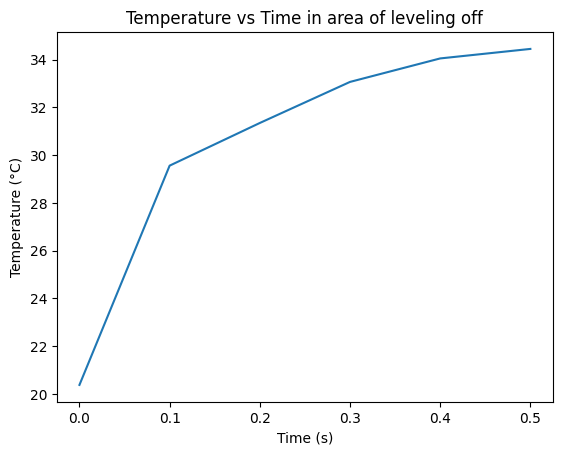

In [366]:
print(T[i0_t:i1_t])
temp_t = temp_t [:-1]

plt.plot(temp_t, T[i0_t:i1_t])

plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Time in area of leveling off')

In [367]:
T_const = 40

Text(0.5, 1.0, 'Fraction of Completion vs Time')

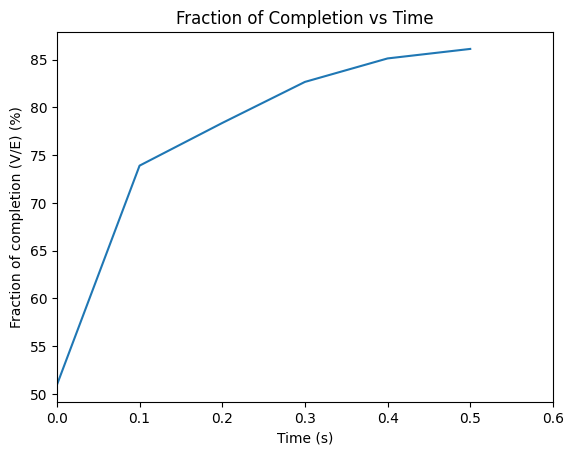

In [368]:
# Fraction of completeion
# Calculate the fraction of completion as V/E, starting at t = 0
f_t = T[i0_t:i1_t] / T_const * 100
plt.plot(temp_t,f_t)
plt.xlabel('Time (s)')
plt.ylabel('Fraction of completion (V/E) (%)')
plt.xlim(0, t1T)
plt.title('Fraction of Completion vs Time')

In [369]:
# Calculate the tau as inverse slope f -ln(1-f) , and fit a line to it
x_t = temp_t
y_t = -np.log(1-f_t/100)
m_t = np.sum((x_t - np.mean(x_t)) * (y_t - np.mean(y_t))) / np.sum((x_t - np.mean(x_t))**2) 
b_t = np.mean(y_t) - m_t * np.mean(x_t)
tau_t = 1/m_t
print(f'The time constant of the Thermocouple calculated using the inverse slope method is {tau_t:.1f} s')

The time constant of the Thermocouple calculated using the inverse slope method is 0.4 s


Text(0.5, 1.0, 'Inverse Slope Fraction of Completion vs Time')

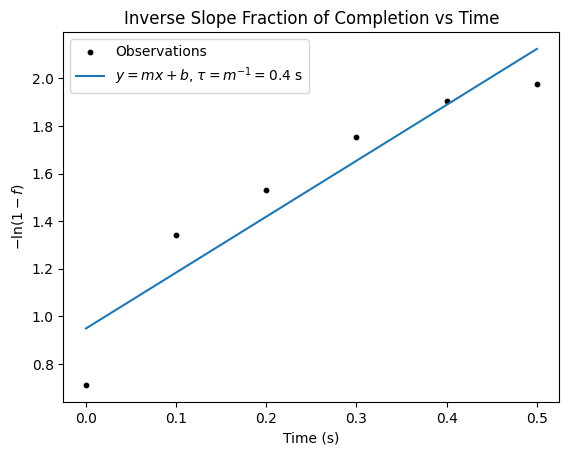

In [370]:
plt.scatter(x_t,y_t,s=10,c='k',label='Observations')
plt.plot(temp_t,m_t*temp_t+b_t,label=r'$y=mx+b$, $\tau = m^{-1} = %.1f$ s' % tau_t)
plt.legend()
plt.ylabel(r'$- \ln (1-f)$')
plt.xlabel('Time (s)')
plt.title ('Inverse Slope Fraction of Completion vs Time')